# **Image Classification using CIFAR-10**

> ### **Introduction**:

Image classification is a fundamental task in computer vision that involves assigning labels to images based on their visual content. Convolutional Neural Networks (CNNs) are widely used for this task because they can automatically learn important features from images using convolution and pooling layers. In this assignment, a CNN model is developed to classify images from the CIFAR-10 dataset. The model includes convolutional, pooling, and fully connected layers, and its performance is evaluated using accuracy and loss curves

> ### **Overview**

* Develop a Convolutional Neural Network (CNN) for image classification.

* Use the CIFAR-10 dataset containing 10 image classes.

* Design the model with convolutional, pooling, and fully connected layers.

* Train the CNN using TensorFlow/Keras.

* Evaluate model performance using accuracy and loss curves.

## **Importing Required Libraries**

In [20]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import cifar10


* Conv2D → convolution layer

* MaxPooling2D → pooling layer

* Dense → fully connected layer

### **Load CIFAR-10 Dataset**

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 44s 0us/step


c:\Users\jikum\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")




> **In this CIFAR-10 dataset**

* 50,000 training images

* 10,000 testing images

### **Data Preprocessing**

In [3]:
# Normalize pixel values (0–255 → 0–1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)


> Normalization helps faster and stable training

### **Class Labels**

In [5]:
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']


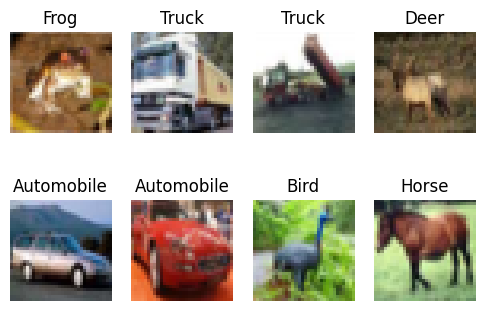

In [6]:
plt.figure(figsize=(6,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(X_train[i], interpolation='nearest')
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()


## **Build CNN Model**

In [7]:
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Convolution Layer 3
model.add(Conv2D(64, (3,3), activation='relu'))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))


c:\Users\jikum\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary() # Model Summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

**Explanation**:

* Convolution layers → feature extraction

* Pooling layers → dimensionality reduction

* Dense layers → classification

### **Compile the Model**

In [9]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])


### **Train the Model**

In [10]:
history = model.fit(X_train, y_train,epochs=10,batch_size=64,validation_data=(X_test, y_test))


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.3465 - loss: 1.7555 - val_accuracy: 0.5024 - val_loss: 1.3895
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.4940 - loss: 1.4012 - val_accuracy: 0.5715 - val_loss: 1.1850
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.5485 - loss: 1.2640 - val_accuracy: 0.6018 - val_loss: 1.1277
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.5826 - loss: 1.1736 - val_accuracy: 0.6138 - val_loss: 1.0808
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.6147 - loss: 1.0929 - val_accuracy: 0.6518 - val_loss: 0.9859
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.6338 - loss: 1.0415 - val_accuracy: 0.6568 - val_loss: 0.9653
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.6525 - loss: 0.9920 - val_accuracy: 0.6758 - val_loss: 0.9293
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.6693 - loss: 0.9543 - 

# **Accuracy Graph**

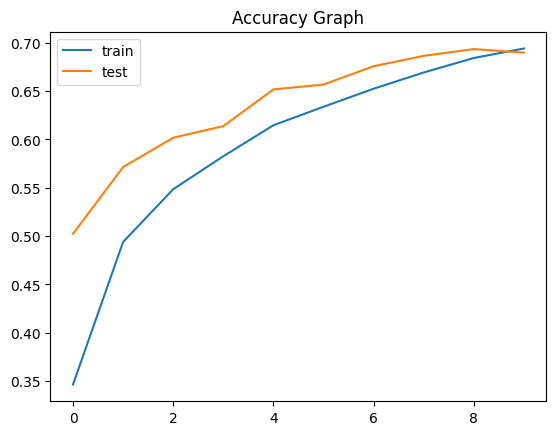

In [11]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

### **Evaluate Model Performance**

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

In [14]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

           0       0.67      0.79      0.73      1000
           1       0.84      0.83      0.83      1000
           2       0.52      0.61      0.56      1000
           3       0.53      0.43      0.48      1000
           4       0.61      0.66      0.63      1000
           5       0.60      0.60      0.60      1000
           6       0.73      0.78      0.76      1000
           7       0.76      0.70      0.73      1000
           8       0.86      0.74      0.80      1000
           9       0.83      0.75      0.79      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



## **Confusion Matrix**

In [17]:
import seaborn as sns

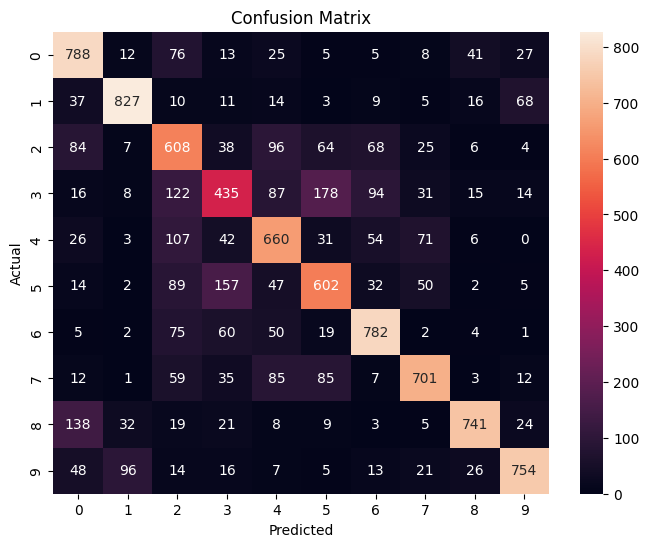

In [18]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### **Plot Training & Validation Accuracy**

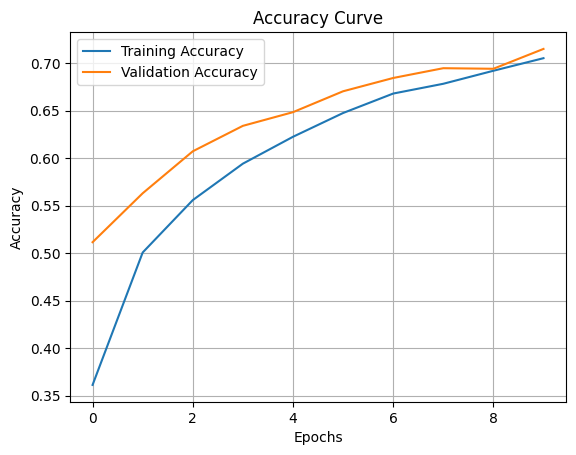

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()


### **Plot Training & Validation Loss**

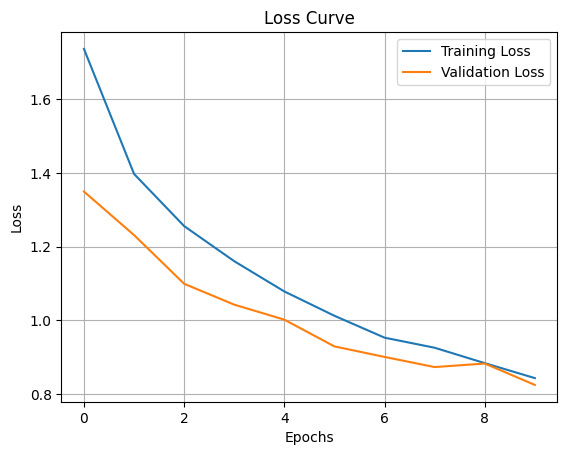

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


### **Prediction on Test Images**

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


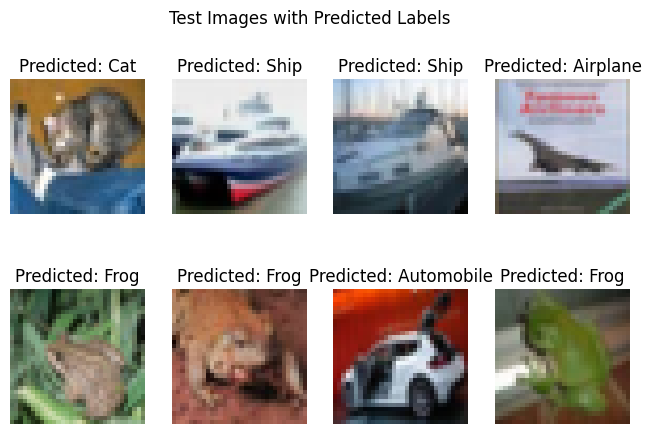

In [ ]:
# Class names for CIFAR-10 dataset
class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

# Generate predictions for test images
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

# Plot test images with predicted labels
plt.figure(figsize=(8,5))

for i in range(8):
    plt.subplot(2,4,i+1)

    # Display test image
    plt.imshow(X_test[i], interpolation='nearest')

    # Show predicted class
    plt.title("Predicted: " + class_names[predicted_labels[i]])

    plt.axis('off')

plt.suptitle("Test Images with Predicted Labels")
plt.show()


 ## **Conclusion**

> This project successfully demonstrates the implementation of a Convolutional Neural Network for image classification using the CIFAR-10 dataset. The model effectively learns hierarchical features from images and achieves good classification performance.

Through experimentation with different kernel sizes, activation functions, and network depths, it is observed that model architecture plays a crucial role in performance. Visualization of convolutional and pooling layers provides a deeper understanding of how CNNs process and extract meaningful patterns from images.

Overall, CNNs prove to be highly effective for image classification tasks, and further improvements such as data augmentation, regularization, and deeper architectures can enhance performance even more.